# Импорты

In [1]:
import asyncio
import sys
import time
from collections import Counter
from pathlib import Path

import pandas as pd
from openai import AsyncOpenAI
from transformers import AutoTokenizer

sys.path.append(str(Path.cwd().parent))

from generation import generate_one
from io_utils import load_jsonl
from long_input import prepare_product_input

# Параметры генерации

In [2]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

generation_params = {
    "temperature": 0.5,
    "top_p": 0.9,
    "repetition_penalty": 1.1,
    "max_tokens": 250,
    "seed": 42,
}

# Клиент и данные

In [3]:
client = AsyncOpenAI(
    base_url="http://localhost:8000/v1",
    api_key="EMPTY",
    timeout=120,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

benchmark = load_jsonl("../data/benchmark.jsonl")

len(benchmark)

300

# Обработка длинного входа

In [4]:
started = time.perf_counter()
prepared_benchmark = [
    prepare_product_input(
        product=product,
        tokenizer=tokenizer,
        max_input_tokens=1500,
    )
    for product in benchmark
]
time_s = time.perf_counter() - started

print(f"Общее время, с: {time_s:.4f}")
print(f"Среднее время на карточку, с: {time_s / len(benchmark) :.4f}")

Общее время, с: 22.8247
Среднее время на карточку, с: 0.0761


In [5]:
from long_input import count_input_tokens

num_tokens = [
    count_input_tokens(product, tokenizer)
    for product in prepared_benchmark
]

print(f"Обработано карточек: {len(num_tokens)}")
print(f"Максимальный вход: {max(num_tokens)}")
print(f"Средний вход: {sum(num_tokens) / len(num_tokens) :.2f}")

Обработано карточек: 300
Максимальный вход: 1500
Средний вход: 1188.88


# Генерация одной карточки с замером latency

In [6]:
async def generate_timed(product, client, model_name, generation_params):
    """Генерирует одну карточку и измеряет её latency."""
    started = time.perf_counter()

    result = await generate_one(
        client=client,
        model_name=model_name,
        source_product=product,
        generation_params=generation_params,
        max_attempts=2,
    )

    latency = time.perf_counter() - started

    return result, latency

In [7]:
async def run_concurrent(items, concurrency, generate_one):
    """Отправляет запросы параллельно, не больше concurrency одновременно."""
    sem = asyncio.Semaphore(concurrency)

    async def wrapped(item):
        async with sem:
            return await generate_one(item)

    started = time.perf_counter()

    results = await asyncio.gather(
        *[wrapped(item) for item in items]
    )

    elapsed = time.perf_counter() - started

    return results, elapsed

# Расчет метрик

In [8]:
def calculate_metrics(run_results, elapsed_sec):
    """Вычисляет метрики пакетного прогона."""
    results = [result for result, _ in run_results]
    latencies = [latency for _, latency in run_results]

    n = len(results)
    valid = sum(result.valid for result in results)

    errors_by_reason = Counter(
        reason.value
        for result in results
        if not result.valid
        for reason in set(result.errors)
    )

    return {
        "n": n,
        "valid": valid,
        "valid_rate": valid / n,
        "elapsed_sec": elapsed_sec,
        "throughput": n / elapsed_sec,
        "avg_latency": sum(latencies) / n,
        "time_for_300_sec": 300 / (n / elapsed_sec),
        "avg_attempts": sum(result.attempts for result in results) / n,
        "input_tokens": sum(result.input_tokens for result in results),
        "output_tokens": sum(result.output_tokens for result in results),
        "errors_by_reason": dict(errors_by_reason),
    }

# Пакетный прогон

In [9]:
async def test_run():
    async def generate(product):
        return await generate_timed(
            product=product,
            client=client,
            model_name=model_name,
            generation_params=generation_params,
        )

    run_results, elapsed = await run_concurrent(
        items=prepared_benchmark[:5],
        concurrency=2,
        generate_one=generate,
    )

    return calculate_metrics(run_results, elapsed)


test_metrics = await test_run()
test_metrics

{'n': 5,
 'valid': 4,
 'valid_rate': 0.8,
 'elapsed_sec': 29.34517330099993,
 'throughput': 0.1703857717490333,
 'avg_latency': 11.58510578839996,
 'time_for_300_sec': 1760.7103980599957,
 'avg_attempts': 1.6,
 'input_tokens': 10585,
 'output_tokens': 1618,
 'errors_by_reason': {'description_length': 1, 'output_truncated': 1}}

In [10]:
experiment_items = prepared_benchmark[:40]

len(experiment_items)

40

In [11]:
async def run_benchmark(
    items,
    concurrency,
    client,
    model_name,
    generation_params,
):
    """Запускает пакетный прогон и рассчитывает его метрики."""

    async def generate(product):
        return await generate_timed(
            product=product,
            client=client,
            model_name=model_name,
            generation_params=generation_params,
        )

    run_results, elapsed = await run_concurrent(
        items=items,
        concurrency=concurrency,
        generate_one=generate,
    )

    metrics = calculate_metrics(run_results, elapsed)

    return run_results, metrics

In [12]:
experiment_results = []

for concurrency in [1, 4, 16, 32, 40]:
    _, metrics = await run_benchmark(
        items=experiment_items,
        concurrency=concurrency,
        client=client,
        model_name=model_name,
        generation_params=generation_params,
    )

    experiment_results.append({
        "concurrency": concurrency,
        **metrics,
    })

    print(
        f"concurrency={concurrency}: "
        f"throughput={metrics['throughput']:.2f} card/s, "
        f"latency={metrics['avg_latency']:.2f} s, "
        f"valid={metrics['valid_rate']:.1%}"
    )

concurrency=1: throughput=0.18 card/s, latency=5.55 s, valid=90.0%
concurrency=4: throughput=0.55 card/s, latency=7.19 s, valid=87.5%
concurrency=16: throughput=1.05 card/s, latency=13.06 s, valid=87.5%
concurrency=32: throughput=1.16 card/s, latency=20.29 s, valid=90.0%
concurrency=40: throughput=1.23 card/s, latency=24.30 s, valid=90.0%


In [13]:
experiment_df = pd.DataFrame(experiment_results)

experiment_df[
    [
        "concurrency",
        "throughput",
        "avg_latency",
        "valid_rate",
        "elapsed_sec",
        "time_for_300_sec",
        "avg_attempts",
    ]
].round(3)

,concurrency,throughput,avg_latency,valid_rate,elapsed_sec,time_for_300_sec,avg_attempts
0,1,0.180,5.550,0.900,221.990,1664.923,1.350
1,4,0.549,7.187,0.875,72.852,546.392,1.350
2,16,1.051,13.056,0.875,38.061,285.454,1.325
3,32,1.160,20.289,0.900,34.484,258.629,1.325
4,40,1.234,24.301,0.900,32.407,243.052,1.350


In [17]:
prefix_cache_results = []

for concurrency in [16, 32, 40]:
    _, metrics = await run_benchmark(
        items=experiment_items,
        concurrency=concurrency,
        client=client,
        model_name=model_name,
        generation_params=generation_params,
    )

    prefix_cache_results.append({
        "concurrency": concurrency,
        **metrics,
    })

    print(
        f"concurrency={concurrency}: "
        f"throughput={metrics['throughput']:.3f} card/s, "
        f"latency={metrics['avg_latency']:.3f} s, "
        f"valid={metrics['valid_rate']:.1%}"
    )

concurrency=16: throughput=1.328 card/s, latency=10.128 s, valid=90.0%
concurrency=32: throughput=1.507 card/s, latency=14.719 s, valid=90.0%
concurrency=40: throughput=1.707 card/s, latency=16.673 s, valid=90.0%


In [18]:
prefix_cache_df = pd.DataFrame(prefix_cache_results)

prefix_cache_df[
    [
        "concurrency",
        "throughput",
        "avg_latency",
        "valid_rate",
        "elapsed_sec",
        "time_for_300_sec",
        "avg_attempts",
    ]
].round(3)

,concurrency,throughput,avg_latency,valid_rate,elapsed_sec,time_for_300_sec,avg_attempts
0,16,1.328,10.128,0.9,30.130,225.974,1.325
1,32,1.507,14.719,0.9,26.551,199.132,1.350
2,40,1.707,16.673,0.9,23.431,175.729,1.325


<Axes: title={'center': 'Throughput в зависимости от concurrency'}, xlabel='concurrency', ylabel='карточек / сек'>

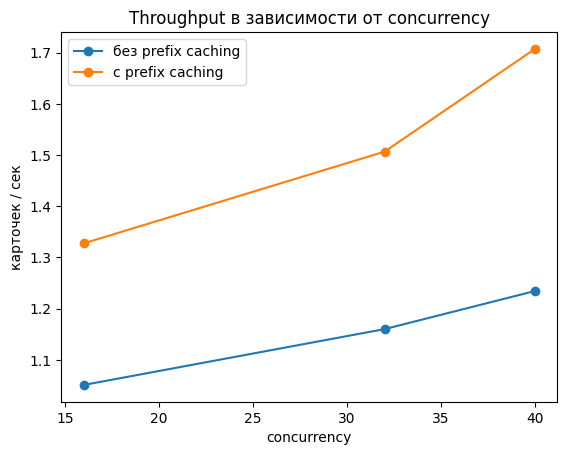

In [20]:
throughput_df = (
    experiment_df[["concurrency", "throughput"]]
    .merge(
        prefix_cache_df[["concurrency", "throughput"]],
        on="concurrency",
        suffixes=("_without_cache", "_with_cache"),
    )
)

throughput_df.plot(
    x="concurrency",
    y=["throughput_without_cache", "throughput_with_cache"],
    marker="o",
    ylabel="карточек / сек",
    title="Throughput в зависимости от concurrency",
    label=["без prefix caching", "с prefix caching"],
)

<Axes: title={'center': 'Средняя latency в зависимости от concurrency'}, xlabel='concurrency', ylabel='секунды'>

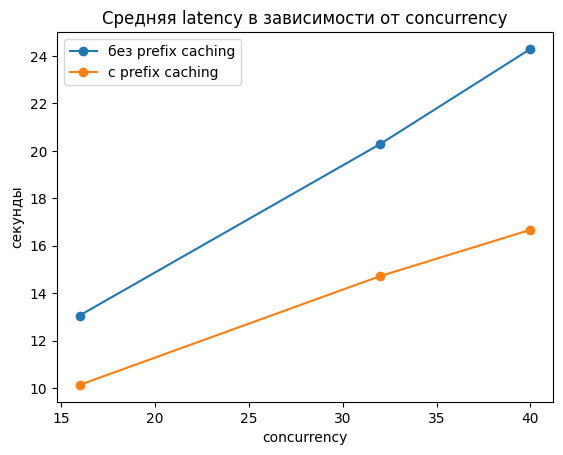

In [21]:
latency_df = (
    experiment_df[["concurrency", "avg_latency"]]
    .merge(
        prefix_cache_df[["concurrency", "avg_latency"]],
        on="concurrency",
        suffixes=("_without_cache", "_with_cache"),
    )
)

latency_df.plot(
    x="concurrency",
    y=["avg_latency_without_cache", "avg_latency_with_cache"],
    marker="o",
    ylabel="секунды",
    title="Средняя latency в зависимости от concurrency",
    label=["без prefix caching", "с prefix caching"],
)

In [22]:
quality_df = (
    experiment_df[
        ["concurrency", "valid_rate", "avg_attempts"]
    ]
    .merge(
        prefix_cache_df[
            ["concurrency", "valid_rate", "avg_attempts"]
        ],
        on="concurrency",
        suffixes=("_without_cache", "_with_cache"),
    )
)

quality_df

,concurrency,valid_rate_without_cache,avg_attempts_without_cache,valid_rate_with_cache,avg_attempts_with_cache
0,16,0.875,1.325,0.9,1.325
1,32,0.900,1.325,0.9,1.350
2,40,0.900,1.350,0.9,1.325


# Финальный прогон

In [21]:
_ , _ = await run_benchmark(
    items=prepared_benchmark[:5],
    concurrency=4,
    client=client,
    model_name=model_name,
    generation_params=generation_params,
)

In [13]:
experiment_items_large = prepared_benchmark[:80]

In [14]:
high_concurrency_results = []

for concurrency in [40, 48, 64]:
    _, metrics = await run_benchmark(
        items=experiment_items_large,
        concurrency=concurrency,
        client=client,
        model_name=model_name,
        generation_params=generation_params,
    )

    high_concurrency_results.append({
        "concurrency": concurrency,
        **metrics,
    })

    print(
        f"concurrency={concurrency}: "
        f"throughput={metrics['throughput']:.3f} card/s, "
        f"latency={metrics['avg_latency']:.3f} s, "
        f"valid={metrics['valid_rate']:.1%}"
    )

concurrency=40: throughput=1.670 card/s, latency=19.341 s, valid=93.8%
concurrency=48: throughput=1.987 card/s, latency=19.739 s, valid=93.8%
concurrency=64: throughput=2.039 card/s, latency=22.236 s, valid=93.8%


In [15]:
selected_concurrency = 48

In [16]:
full_results, full_metrics = await run_benchmark(
        items=prepared_benchmark,
        concurrency=selected_concurrency,
        client=client,
        model_name=model_name,
        generation_params=generation_params,
)

full_metrics

{'n': 300,
 'valid': 271,
 'valid_rate': 0.9033333333333333,
 'elapsed_sec': 153.14137269399998,
 'throughput': 1.9589742126671814,
 'avg_latency': 23.01176703935667,
 'time_for_300_sec': 153.14137269399998,
 'avg_attempts': 1.2633333333333334,
 'input_tokens': 471414,
 'output_tokens': 75455,
 'errors_by_reason': {'description_length': 8,
  'wrong_list_length': 18,
  'output_truncated': 13,
  'description_sentence_count': 5}}

In [17]:
print(f"Карточек: {full_metrics['n']}")
print(f"Валидных: {full_metrics['valid']}")
print(f"Доля валидных: {full_metrics['valid_rate']:.1%}")
print(f"Время: {full_metrics['elapsed_sec']:.1f} сек")
print(f"Throughput: {full_metrics['throughput']:.2f} карточек/сек")
print(f"Средняя latency: {full_metrics['avg_latency']:.2f} сек")
print(f"Среднее число попыток: {full_metrics['avg_attempts']:.2f}")

print()
print(f"Качество >= 80%: {full_metrics['valid_rate'] >= 0.80}")
print(f"Время <= 8 минут: {full_metrics['elapsed_sec'] <= 480}")

Карточек: 300
Валидных: 271
Доля валидных: 90.3%
Время: 153.1 сек
Throughput: 1.96 карточек/сек
Средняя latency: 23.01 сек
Среднее число попыток: 1.26

Качество >= 80%: True
Время <= 8 минут: True


In [18]:
full_metrics["errors_by_reason"]

{'description_length': 8,
 'wrong_list_length': 18,
 'output_truncated': 13,
 'description_sentence_count': 5}

In [19]:
cost_vllm_per_1000 = (
        full_metrics["elapsed_sec"] / 3600 * 65
        / full_metrics["n"]
        * 1000
)

print(f"Стоимость 1000 карточек: {cost_vllm_per_1000:.2f} ₽")
print(f"Стоимость <= 25 ₽: {cost_vllm_per_1000 <= 25}")

Стоимость 1000 карточек: 9.22 ₽
Стоимость <= 25 ₽: True


# Сравнение FP16 и INT4

In [20]:
fp16_metrics = next(
    result
    for result in high_concurrency_results
    if result["concurrency"] == 48
)

fp16_metrics

{'concurrency': 48,
 'n': 80,
 'valid': 75,
 'valid_rate': 0.9375,
 'elapsed_sec': 40.25460837800006,
 'throughput': 1.9873501003607226,
 'avg_latency': 19.73856806272501,
 'time_for_300_sec': 150.95478141750021,
 'avg_attempts': 1.2375,
 'input_tokens': 123365,
 'output_tokens': 20108,
 'errors_by_reason': {'description_length': 3,
  'wrong_list_length': 2,
  'output_truncated': 2,
  'description_sentence_count': 1}}

In [22]:
_, int4_metrics = await run_benchmark(
    items=experiment_items_large,
    concurrency=48,
    client=client,
    model_name=model_name,
    generation_params=generation_params,
)

int4_metrics

{'n': 80,
 'valid': 68,
 'valid_rate': 0.85,
 'elapsed_sec': 164.8787107889998,
 'throughput': 0.48520515242491424,
 'avg_latency': 79.15185934743752,
 'time_for_300_sec': 618.2951654587492,
 'avg_attempts': 1.4,
 'input_tokens': 139945,
 'output_tokens': 22791,
 'errors_by_reason': {'description_sentence_count': 2,
  'wrong_list_length': 7,
  'output_truncated': 8,
  'description_length': 5}}

In [23]:
precision_comparison = pd.DataFrame([
    {
        "precision": "FP16",
        "throughput": fp16_metrics["throughput"],
        "avg_latency": fp16_metrics["avg_latency"],
        "valid_rate": fp16_metrics["valid_rate"],
        "avg_attempts": fp16_metrics["avg_attempts"],
        "elapsed_sec": fp16_metrics["elapsed_sec"],
    },
    {
        "precision": "INT4",
        "throughput": int4_metrics["throughput"],
        "avg_latency": int4_metrics["avg_latency"],
        "valid_rate": int4_metrics["valid_rate"],
        "avg_attempts": int4_metrics["avg_attempts"],
        "elapsed_sec": int4_metrics["elapsed_sec"],
    },
])

precision_comparison.round(3)

,precision,throughput,avg_latency,valid_rate,avg_attempts,elapsed_sec
0,FP16,1.987,19.739,0.938,1.238,40.255
1,INT4,0.485,79.152,0.850,1.400,164.879


In [24]:
print("FP16:")
print(fp16_metrics["errors_by_reason"])

print()

print("INT4:")
print(int4_metrics["errors_by_reason"])

FP16:
{'description_length': 3, 'wrong_list_length': 2, 'output_truncated': 2, 'description_sentence_count': 1}

INT4:
{'description_sentence_count': 2, 'wrong_list_length': 7, 'output_truncated': 8, 'description_length': 5}
